# 05 - Convolutional Autoencoders (CNN Autoencoders) on MNIST (GPU Accelerated)

This notebook covers the design, implementation, and training of **Convolutional Autoencoders (CNN Autoencoders)** in PyTorch on the **MNIST dataset**, featuring **CUDA GPU Acceleration**, detailed mathematical layer dimensions, latent space representation, and image denoising applications.

---

## Modern Architecture & Engineering Objectives:

1. **GPU Acceleration**: Dynamically configuring `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')` and moving network models and tensors onto the active compute device.
2. **Convolutional Encoder**: Downsampling spatial dimensions ($28 \times 28 \rightarrow 14 \times 14 \rightarrow 7 \times 7$) using `nn.Conv2d` and `nn.MaxPool2d` while learning hierarchical feature maps ($1 \rightarrow 16 \rightarrow 8$ channels).
3. **Transposed Convolutional Decoder**: Upsampling spatial bottleneck representations back to full image dimensions ($7 \times 7 \rightarrow 14 \times 14 \rightarrow 28 \times 28$) using `nn.ConvTranspose2d` with stride=2, padding=1, and output_padding=1.
4. **End-to-End Image Reconstruction & Denoising**: Training the CNN autoencoder using Mean Squared Error loss (`nn.MSELoss`) to reconstruct clean handwritten digits and eliminate synthetic Gaussian noise.


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline

import torch
import torch.nn as nn
import torch.nn.functional as F

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# GPU Device Selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Matplotlib visual configuration
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print(f"PyTorch Version: {torch.__version__}")
print(f"Using Device:    {device}")
if torch.cuda.is_available():
    print(f"GPU Name:        {torch.cuda.get_device_name(0)}")


PyTorch Version: 2.11.0+cu128
Using Device:    cuda
GPU Name:        Tesla T4


## 1. Loading & Preprocessing MNIST Dataset

Convolutional Autoencoders process 2D spatial feature maps. We load the normalized pixel data and reshape flattened vectors into $(N, C, H, W) = (N, 1, 28, 28)$ image tensors.

- **Normalization**: Scaling pixel intensities to $[0, 1]$.
- **Tensor Format**: Reshaping from 784-dimensional flat vectors to $(N, 1, 28, 28)$ 4D tensors required by PyTorch `Conv2d` and `ConvTranspose2d` layers.


In [9]:
# Load MNIST small dataset (with fallback for standalone execution)
if os.path.exists('sample_data/mnist_train_small.csv'):
    data = np.loadtxt(open('sample_data/mnist_train_small.csv', 'rb'), delimiter=',')
    data = data[:, 1:] # Drop label column
    data_norm = data / np.max(data) # Normalize to [0, 1]
    dataT = torch.tensor(data_norm, dtype=torch.float32).view(-1, 1, 28, 28)
else:
    import torchvision
    import torchvision.transforms as T
    mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=T.ToTensor())
    dataT = mnist_dataset.data.unsqueeze(1).float() / 255.0

print(f"MNIST Data Tensor Shape: {dataT.shape} (N, C, H, W)")
print(f"Pixel Value Range:       [{dataT.min():.1f}, {dataT.max():.1f}]")


MNIST Data Tensor Shape: torch.Size([20000, 1, 28, 28]) (N, C, H, W)
Pixel Value Range:       [0.0, 1.0]


## 2. Creating the CNN Autoencoder Architecture

An autoencoder consists of two complementary components:

1. **Encoder $E(x)$**: Compresses spatial input $X \in \mathbb{R}^{1 \times 28 \times 28}$ into a lower-dimensional latent bottleneck representation $Z \in \mathbb{R}^{8 \times 7 \times 7}$.
2. **Decoder $D(z)$**: Reconstructs the original spatial image $\hat{Y} \in \mathbb{R}^{1 \times 28 \times 28}$ from the bottleneck $Z$.

### Mathematical Layer Transformations:

#### Encoder:

- **`enc1`**: $\text{Conv2d}(1 \rightarrow 16, k=3, p=1) \implies (N, 16, 28, 28)$
- **`pool1`**: $\text{MaxPool2d}(2, 2) \implies (N, 16, 14, 14)$
- **`enc2`**: $\text{Conv2d}(16 \rightarrow 8, k=3, p=1) \implies (N, 8, 14, 14)$
- **`pool2`**: $\text{MaxPool2d}(2, 2) \implies (N, 8, 7, 7)$ (Bottleneck: $8 \times 7 \times 7 = 392$ values)

#### Decoder (Transposed Convolution Output Dimensions):

The spatial output height $H_{out}$ of `ConvTranspose2d` is given by:
$$H_{out} = (H_{in} - 1) \times \text{stride} - 2 \times \text{padding} + \text{kernel\_size} + \text{output\_padding}$$

- **`dec1`**: $\text{ConvTranspose2d}(8 \rightarrow 16, k=3, s=2, p=1, op=1)$
  $$H_{out} = (7 - 1) \times 2 - 2(1) + 3 + 1 = 14 \implies (N, 16, 14, 14)$$
- **`dec2`**: $\text{ConvTranspose2d}(16 \rightarrow 1, k=3, s=2, p=1, op=1)$
  $$H_{out} = (14 - 1) \times 2 - 2(1) + 3 + 1 = 28 \implies (N, 1, 28, 28)$$
- **Output Activation**: `torch.sigmoid` maps output values strictly into $[0, 1]$.


In [10]:
class aenet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder layers
        self.enc1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # output: 16 x 28 x 28
        self.pool1 = nn.MaxPool2d(2, 2)                        # output: 16 x 14 x 14
        self.enc2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)  # output: 8 x 14 x 14
        self.pool2 = nn.MaxPool2d(2, 2)                        # output: 8 x 7 x 7

        # Decoder layers
        self.dec1 = nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1) # output: 16 x 14 x 14
        self.dec2 = nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1) # output: 1 x 28 x 28

    def forward(self, x):
        # Reshape if flat vector input (N, 784) is passed
        if x.ndim == 2:
            x = x.view(-1, 1, 28, 28)

        # Encoder forward pass
        x = F.relu(self.pool1(self.enc1(x)))
        x = F.relu(self.pool2(self.enc2(x)))

        # Decoder forward pass
        x = F.relu(self.dec1(x))
        y = torch.sigmoid(self.dec2(x)) # Normalized output in [0, 1]
        return y

def createTheMNISTAE(device=device):
    # Instantiate model and transfer to target compute device (CPU/GPU)
    net = aenet().to(device)

    # Loss function (Mean Squared Error for pixel-wise reconstruction)
    lossfun = nn.MSELoss()

    # Optimizer
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

    return net, lossfun, optimizer


## 3. Testing the Model Before Training

Before training, we perform a dummy forward pass on a small batch ($N=5$) transferred to the target device (`device`). This verifies tensor dimensions and confirms that input images and output reconstructions match in shape $(5, 1, 28, 28)$.


In [11]:
# Create model instance on active device
net, lossfun, optimizer = createTheMNISTAE(device=device)

# Select first 5 samples and push to GPU/CPU device
X = dataT[:5, :].to(device)

# Forward pass
yHat = net(X)

print(f"Input Shape:          {list(X.shape)} on device: {X.device}")
print(f"Reconstructed Shape:  {list(yHat.shape)} on device: {yHat.device}")

# Calculate total trainable parameters
num_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params:,}")


Input Shape:          [5, 1, 28, 28] on device: cuda:0
Reconstructed Shape:  [5, 1, 28, 28] on device: cuda:0
Total Trainable Parameters: 2,633


**_Visualizing Untrained Forward Pass Results_**

Prior to training, the autoencoder outputs random noise/blur, demonstrating that weight initialization has not yet learned image structures.


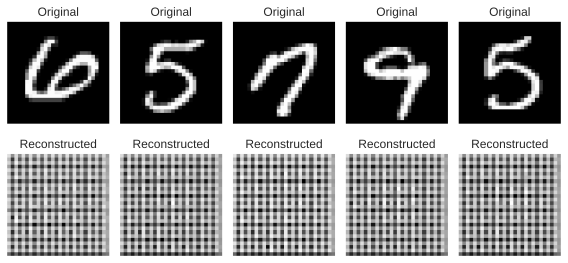

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

X_cpu = X.cpu().detach().numpy()
yHat_cpu = yHat.cpu().detach().numpy()

for i in range(5):
    axes[0, i].imshow(X_cpu[i, 0, :, :], cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(yHat_cpu[i, 0, :, :], cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


## 4. Training the Model (GPU Accelerated)

We train the autoencoder using mini-batch stochastic gradient descent over 10,000 iterations:

- **Batch Size**: 32 randomly selected samples per iteration.
- **Loss Function**: Mean Squared Error ($\text{MSE}$) computed as:
  $$\mathcal{L}(X, \hat{Y}) = \frac{1}{N \cdot C \cdot H \cdot W} \sum_{i=1}^{N} ||X_i - \hat{Y}_i||_2^2$$
- **GPU Optimization**: Mini-batch tensors $X$ are loaded directly onto the GPU during each iteration.


In [13]:
def train_model(epochs=10000, batch_size=32, device=device):
    net, lossfun, optimizer = createTheMNISTAE(device=device)
    losses = torch.zeros(epochs)

    for i in range(epochs):
        # Randomly select mini-batch indices
        randomidx = np.random.choice(dataT.shape[0], size=batch_size)
        X = dataT[randomidx, :].to(device)

        # Forward pass
        yHat = net(X)

        # Compute loss
        loss = lossfun(yHat, X)
        losses[i] = loss.item()

        # Backward pass & parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Progress update every 2000 epochs
        if (i + 1) % 2000 == 0:
            print(f"Epoch [{i+1}/{epochs}] - Loss: {loss.item():.6f}")

    return losses, net


Epoch [2000/10000] - Loss: 0.006604
Epoch [4000/10000] - Loss: 0.005508
Epoch [6000/10000] - Loss: 0.004942
Epoch [8000/10000] - Loss: 0.004790
Epoch [10000/10000] - Loss: 0.004205


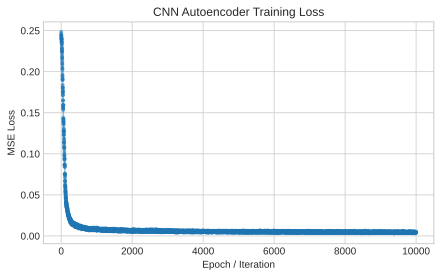

In [14]:
losses, net = train_model(epochs=10000, batch_size=32, device=device)

plt.figure(figsize=(7, 4))
plt.plot(losses.numpy(), '.-', alpha=0.5)
plt.xlabel('Epoch / Iteration')
plt.ylabel('MSE Loss')
plt.title('CNN Autoencoder Training Loss')
plt.show()


## 5. Visualizing Reconstructed Digits

After training, we feed 5 test digits through the trained CNN Autoencoder on the GPU to inspect the fidelity of the reconstructed outputs.


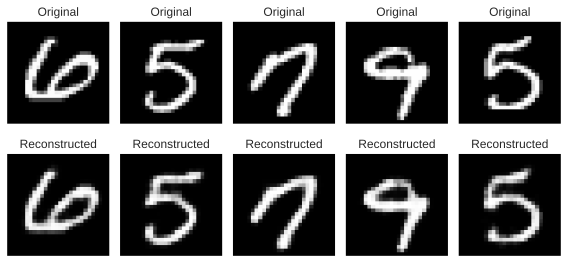

In [15]:
X = dataT[:5, :].to(device)
yHat = net(X)

fig, axes = plt.subplots(2, 5, figsize=(8, 4))

X_cpu = X.cpu().detach().numpy()
yHat_cpu = yHat.cpu().detach().numpy()

for i in range(5):
    axes[0, i].imshow(X_cpu[i, 0, :, :], cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(yHat_cpu[i, 0, :, :], cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


## 6. Denoising Images Using the CNN Autoencoder

Convolutional Autoencoders act as natural regularizers for spatial noise. Since noise contains high-frequency spatial variation without semantic structure, passing noisy images through the bottleneck forces the decoder to reconstruct only the learned manifold of clean digit structures.

### Noise Addition Process:

$$X_{\text{noisy}} = \text{clip}(X + \mathcal{U}(0, 0.25), 0, 1)$$


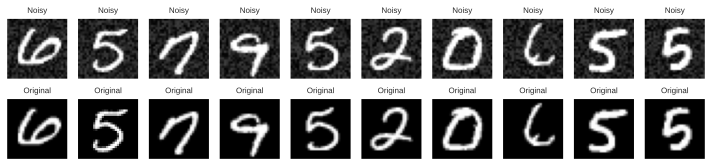

In [16]:
X = dataT[:10, :].to(device)

# Add uniform noise and clip to valid intensity range [0, 1]
Xnoise = X + torch.rand_like(X) / 4.0
Xnoise = torch.clamp(Xnoise, 0.0, 1.0)

fig, axes = plt.subplots(2, 10, figsize=(10, 2.5))

Xnoise_cpu = Xnoise.cpu().detach().numpy()
X_cpu = X.cpu().detach().numpy()

for i in range(10):
    axes[0, i].imshow(Xnoise_cpu[i, 0, :, :], cmap='gray')
    axes[0, i].set_title('Noisy', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(X_cpu[i, 0, :, :], cmap='gray')
    axes[1, i].set_title('Original', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


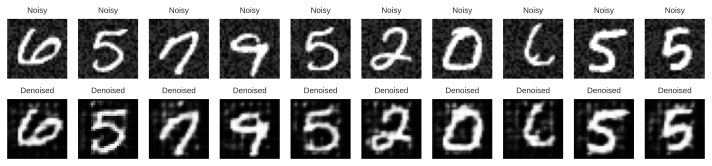

In [17]:
# Pass noisy images through the trained model on GPU
yHat = net(Xnoise)

fig, axes = plt.subplots(2, 10, figsize=(10, 2.5))

yHat_cpu = yHat.cpu().detach().numpy()

for i in range(10):
    axes[0, i].imshow(Xnoise_cpu[i, 0, :, :], cmap='gray')
    axes[0, i].set_title('Noisy', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(yHat_cpu[i, 0, :, :], cmap='gray')
    axes[1, i].set_title('Denoised', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
